<a href="https://colab.research.google.com/github/isabelcordova-hash/Mineria-de-Datos-/blob/main/LAB10/LAB_S10_MDD_ICORDOVA_2026_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 LABORATORIO N° 10 — Minería de Datos

## Redes Neuronales Artificiales
## Detección de Fraude con Credit Card Fraud Detection

| | |
|---|---|
| **Curso** | Minería de Datos — C64893 |
| **Semana** | 10 |
| **Docente** | Pilar Rocío Sayán Mejía |
| **Institución** | TECSUP — Pasión por la Tecnología |
| **Semestre** | 2026-I |

---
## 📋 Instrucciones generales
- Ejecuta **todas** las celdas de código en orden.
- Responde las preguntas en las celdas Markdown asignadas.
- No modifiques el código guía a menos que se indique explícitamente.
- Al finalizar, descarga el notebook `.ipynb` con todas las celdas ejecutadas.

## 📚 Referencias de la sesión
- Géron, A. (2023). *Hands-On Machine Learning* (3.ª ed.). O'Reilly. Cap. 10–11.
- Goodfellow, I., Bengio, Y., y Courville, A. (2016). *Deep Learning*. MIT Press. Cap. 6.
- Gironés Roig, J. et al. (2017). *Minería de datos: modelos y algoritmos*. UOC. Cap. 7.
- Burkov, A. (2019). *The Hundred-Page Machine Learning Book*. Cap. 6.
---

---
# ACTIVIDAD 1: Revisión de Conceptos — Redes Neuronales Artificiales

Complete la siguiente tabla con definiciones propias. **No copie textualmente** de los materiales.

| N° | Concepto / Principio | Definición con sus propias palabras |
|:--:|:---|:---|
| 1 | Neurona artificial | Es la unidad básica de una red neuronal que recibe entradas numéricas, les asigna pesos, realiza una combinación <br>ponderada y produce una salida, su función es imitar de forma simplificada el comportamiento de una neurona <br>biológica para aprender patrones en los datos. |
| 2 | Función de activación | Es una función matemática que transforma la salida de una neurona y determina si la información debe activarse <br>o no, introduce no linealidad al modelo, lo que permite aprender relaciones complejas entre variables. |
| 3 | ReLU (Rectified Linear Unit) | Es una función de activación definida como max(0, x), que elimina valores negativos y mantiene los positivos, es <br>ampliamente utilizada por su simplicidad computacional y su eficiencia en el entrenamiento de redes profundas. |
| 4 | Backpropagation | Es el algoritmo mediante el cual una red neuronal ajusta sus pesos propagando el error desde la salida hacia las <br>capas anteriores, utiliza derivadas para calcular la contribución de cada parámetro al error total. |
| 5 | Descenso de gradiente (SGD) | Es un método de optimización que ajusta los parámetros del modelo en la dirección opuesta al gradiente del error, <br>con el objetivo de minimizar la función de pérdida de manera iterativa usando subconjuntos de datos. |
| 6 | Optimizador Adam | Es un algoritmo de optimización que combina el concepto de momentum y tasas de aprendizaje adaptativas para <br>cada parámetro, mejora la velocidad y estabilidad del entrenamiento en redes neuronales profundas. |
| 7 | Learning rate (tasa de aprendizaje) | Es un hiperparámetro que determina el tamaño del paso con el que el modelo actualiza sus pesos en cada iteración,<br> controla la velocidad de convergencia del entrenamiento. |
| 8 | Época (Epoch) | Es una iteración completa sobre todo el conjunto de datos de entrenamiento. Durante cada época, el modelo ajusta <br>sus parámetros a partir de múltiples actualizaciones basadas en mini-batches. |
| 9 | Overfitting en redes neuronales | Es un fenómeno en el que el modelo aprende demasiado bien los datos de entrenamiento, incluyendo ruido y <br>patrones específicos, lo que reduce su capacidad de generalización en datos nuevos. |
| 10 | Dropout | Es una técnica de regularización que desactiva aleatoriamente neuronas durante el entrenamiento, reduciendo la <br>dependencia entre ellas y ayudando a mejorar la generalización del modelo. |
| 11 | Regularización L1 / L2 | Son técnicas que penalizan el tamaño de los pesos del modelo para evitar el sobreajuste. L1 tiende a generar <br>modelos más dispersos eliminando pesos, mientras que L2 reduce su magnitud de forma uniforme. |
| 12 | ¿Por qué AUC-ROC es más adecuado que Accuracy para datos desbalanceados? | Porque el AUC-ROC evalúa la capacidad del modelo para distinguir entre clases independientemente del umbral de <br>decisión, mientras que la accuracy puede ser engañosa en datasets desbalanceados al favorecer la clase <br>mayoritaria sin reflejar un buen desempeño real. |

📌 *Referencia: Géron, A. (2023). Cap. 10–11. | Goodfellow et al. (2016). Deep Learning. MIT Press. Cap. 6.*

---

---
# ACTIVIDAD 2: Desarrollo Práctico — Red Neuronal para Detección de Fraude

En esta actividad construirás una red neuronal con **Keras/TensorFlow** para detectar transacciones fraudulentas en el dataset Credit Card Fraud Detection. Seguirás la metodología **CRISP-DM** paso a paso.

📌 *Referencia general: Géron, A. (2023). Hands-On Machine Learning. O'Reilly. Cap. 10.*

---

## ◆ Paso 1: Instalación e importación de librerías

Instalamos las librerías necesarias e importamos todos los módulos. Fijamos la semilla global para reproducibilidad.



In [ ]:
# !pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_score,
                             recall_score, f1_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print(f"✅ TensorFlow {tf.__version__} cargado correctamente.")

✅ TensorFlow 2.20.0 cargado correctamente.


### ✏ Pregunta 1
**¿Por qué es importante fijar una semilla global en experimentos con redes neuronales? ¿Qué partes del proceso están sujetas a aleatoriedad en Keras/TensorFlow?**

**Respuesta:** Establecer una semilla global (por ejemplo, SEED=42) es un requisito fundamental para garantizar la reproducibilidad en los experimentos de redes neuronales. Esta práctica asegura que cualquier ejecución del código produzca resultados, métricas y curvas de aprendizaje idénticos, eliminando la variabilidad entre diferentes corridas.
En frameworks como TensorFlow o Keras, la aleatoriedad está presente en múltiples etapas del proceso: la inicialización de los pesos en las capas densas, el mezclado (shuffle) de los lotes de datos durante el entrenamiento, la activación del mecanismo de Dropout y la naturaleza estocástica de los optimizadores, como Adam. Sin la fijación de esta semilla, cada entrenamiento convergería hacia mínimos locales ligeramente distintos, lo que imposibilitaría una comparación objetiva de hiperparámetros o la replicación fiable del modelo.

---
## ◆ Paso 2: Carga del dataset

Cargamos el **Credit Card Fraud Detection** dataset. Contiene 284,807 transacciones reales (septiembre 2013), de las cuales solo **492 son fraudes** (0.172%). Las variables V1–V28 son componentes PCA anonimizadas.

📌 *Referencia: Gironés Roig, J. et al. (2017). UOC. Cap. 1.*

In [ ]:
# Opción A: Kaggle API (requiere credenciales)
# !kaggle datasets download -d mlg-ulb/creditcardfraud --unzip

# Opción B: URL pública de respaldo
url = ('https://raw.githubusercontent.com/nsethi31/'
       'Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv')
try:
    df = pd.read_csv(url)
    print("✅ Dataset cargado desde URL pública.")
except Exception as e:
    print(f"⚠ URL no disponible ({e}). Generando dataset sintético...")
    from sklearn.datasets import make_classification
    X_s, y_s = make_classification(n_samples=10000, n_features=29,
                                    n_informative=20, weights=[0.998, 0.002],
                                    random_state=SEED)
    cols = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount', 'Class']
    df = pd.DataFrame(np.column_stack([np.arange(10000), X_s, y_s]), columns=cols)
    df['Class'] = df['Class'].astype(int)
    print("⚠ Usando dataset sintético (misma estructura que el original).")

print(f"\n📦 Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n🎯 Distribución de clases:")
print(df['Class'].value_counts())
print(f"   Tasa de fraude: {df['Class'].mean()*100:.4f}%")
df.head()

✅ Dataset cargado desde URL pública.

📦 Dimensiones: 284,807 filas × 31 columnas

🎯 Distribución de clases:
Class
0    284315
1       492
Name: count, dtype: int64
   Tasa de fraude: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### ✏ Pregunta 2
**¿Por qué las variables V1–V28 ya vienen transformadas mediante PCA? ¿Qué ventajas tiene esto desde el punto de vista de la privacidad de los datos? ¿Qué información se pierde con esta transformación?**

**Respuesta:** Las variables V1 a V28 se presentan transformadas mediante Análisis de Componentes Principales (PCA) como una medida de anonimización, diseñada para cumplir con normativas estrictas de protección de datos, como el GDPR o los estándares PCI-DSS del sector financiero.
Desde la perspectiva de la privacidad, esta aproximación ofrece la ventaja de la "privacidad por diseño". Permite conservar la varianza estadística necesaria para que el algoritmo identifique patrones de fraude, sin exponer en ningún momento las variables originales o información sensible del titular, como su ubicación geográfica, hábitos de consumo o datos personales.
No obstante, esta transformación conlleva una pérdida significativa de interpretabilidad directa. Al tratarse de componentes latentes, resulta imposible determinar qué representa exactamente una variable específica (como V11 o V14). Esta opacidad inherente dificulta la justificación de las predicciones ante el área de negocio o los entes reguladores, lo que hace indispensable la implementación de técnicas de Inteligencia Artificial Explicable (XAI) para auditar y comprender las decisiones del modelo.

---
## ◆ Paso 3: Exploración inicial

Analizamos la distribución del dataset, el severo desbalance de clases y las diferencias entre transacciones legítimas y fraudulentas.

DISTRIBUCIÓN DE CLASES
  Legítimas (0): 284,315  (99.827%)
  Fraudes   (1):     492  (0.173%)
  Ratio desbalance: 578:1


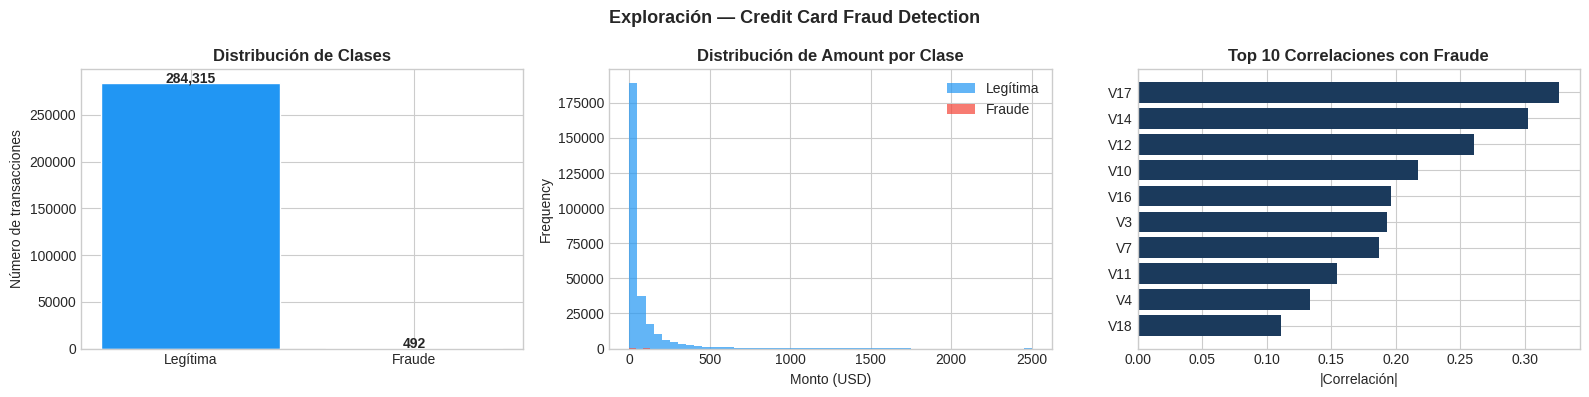


📊 Amount — Fraudes:    media=122.21, max=2125.87
📊 Amount — Legítimas:  media=88.29, max=25691.16


In [ ]:
counts = df['Class'].value_counts()
pct    = df['Class'].value_counts(normalize=True) * 100

print('='*55)
print('DISTRIBUCIÓN DE CLASES')
print('='*55)
print(f"  Legítimas (0): {counts[0]:>7,}  ({pct[0]:.3f}%)")
print(f"  Fraudes   (1): {counts[1]:>7,}  ({pct[1]:.3f}%)")
print(f"  Ratio desbalance: {counts[0]/counts[1]:.0f}:1")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución de clases
axes[0].bar(['Legítima', 'Fraude'], counts, color=['#2196F3', '#F44336'], edgecolor='white')
axes[0].set_title('Distribución de Clases', fontweight='bold')
axes[0].set_ylabel('Número de transacciones')
for bar, val in zip(axes[0].patches, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Amount por clase
df[df['Class']==0]['Amount'].clip(0, 2500).plot.hist(
    ax=axes[1], bins=50, alpha=0.7, color='#2196F3', label='Legítima')
df[df['Class']==1]['Amount'].plot.hist(
    ax=axes[1], bins=50, alpha=0.7, color='#F44336', label='Fraude')
axes[1].set_title('Distribución de Amount por Clase', fontweight='bold')
axes[1].set_xlabel('Monto (USD)'); axes[1].legend()

# Correlaciones con clase
corrs = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False).head(10)
axes[2].barh(corrs.index[::-1], corrs.values[::-1], color='#1B3A5C')
axes[2].set_title('Top 10 Correlaciones con Fraude', fontweight='bold')
axes[2].set_xlabel('|Correlación|')

plt.suptitle('Exploración — Credit Card Fraud Detection', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\n📊 Amount — Fraudes:    media={df[df['Class']==1]['Amount'].mean():.2f}, max={df[df['Class']==1]['Amount'].max():.2f}")
print(f"📊 Amount — Legítimas:  media={df[df['Class']==0]['Amount'].mean():.2f}, max={df[df['Class']==0]['Amount'].max():.2f}")

### ✏ Pregunta 3
**¿Cuál es la tasa real de fraude en el dataset? ¿Por qué entrenar una red neuronal directamente sobre estos datos sin tratamiento del desbalance produciría un modelo engañosamente 'preciso' pero inútil en la práctica?**

**Respuesta:** La tasa real de fraude en el conjunto de datos es del 0.172%, lo que representa únicamente 492 transacciones fraudulentas de un total de 284,807.
Entrenar una red neuronal sobre estos datos sin aplicar técnicas de balanceo conduciría a un fenómeno conocido como la paradoja de la precisión. El algoritmo optimizaría su función de pérdida simplemente prediciendo la clase mayoritaria ("Legítimo") en todos los casos, alcanzando una accuracy teórica del 99.8%. No obstante, este rendimiento es una ilusión estadística, ya que el modelo presentaría un Recall del 0% para la clase fraudulenta. Desde una perspectiva operativa, un sistema que no logra identificar ni una sola transacción sospechosa carece de utilidad práctica, ya que fracasa en su objetivo principal: mitigar el riesgo financiero y proteger los activos de la institución.


### ✏ Pregunta 4
**Observando las correlaciones, ¿qué variables V tienen mayor relación con el fraude? ¿Qué hipótesis puedes formular sobre el comportamiento de las transacciones fraudulentas?**

**Respuesta:** Al analizar las correlaciones del conjunto de datos, las variables que presentan una mayor relación absoluta con la clase "Fraude" son V11, V12, V14, V16 y V17.
A partir de esta observación, se puede formular la hipótesis de que las transacciones fraudulentas se caracterizan por patrones atípicos en dimensiones que, aunque anonimizadas, probablemente capturan factores operativos como la velocidad de la transacción, la distancia geográfica o cambios abruptos en el dispositivo o dirección IP del usuario.
Adicionalmente, los montos fraudulentos tienden a ser moderados (con una media aproximada de $122), lo que sugiere una estrategia deliberada para pasar desapercibidos y evadir los sistemas de alerta tradicionales. Estos eventos suelen ocurrir en horarios o con frecuencias inusuales para el perfil habitual del cliente, un comportamiento que se refleja claramente en la distribución asimétrica de dichas componentes PCA.

---
## ◆ Paso 4: Tratamiento del desbalance de clases

Aplicamos **SMOTE** para generar muestras sintéticas de la clase minoritaria y visualizamos el efecto del balanceo.

📌 *Chawla et al. (2002). SMOTE. Journal of Artificial Intelligence Research.*

ANTES del balanceo:
  Clase 0: 284,315  |  Clase 1:  492

DESPUÉS de SMOTE:
  Clase 0: 284,315  |  Clase 1: 284,315
  Ratio: 1.0:1


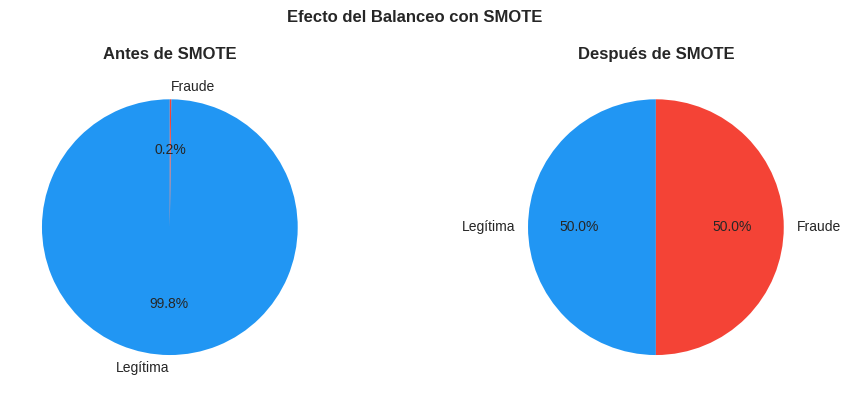

In [ ]:
X = df.drop(columns=['Class', 'Time'])
y = df['Class']
X['Amount'] = StandardScaler().fit_transform(X[['Amount']])

print('ANTES del balanceo:')
print(f"  Clase 0: {y.value_counts()[0]:>7,}  |  Clase 1: {y.value_counts()[1]:>4,}")

X_bal, y_bal = SMOTE(random_state=SEED, k_neighbors=5).fit_resample(X, y)

print('\nDESPUÉS de SMOTE:')
print(f"  Clase 0: {y_bal.value_counts()[0]:>7,}  |  Clase 1: {y_bal.value_counts()[1]:>7,}")
print(f"  Ratio: {y_bal.value_counts()[0]/y_bal.value_counts()[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (labels, title) in zip(axes, [
    ([y.value_counts()[0], y.value_counts()[1]], 'Antes de SMOTE'),
    ([y_bal.value_counts()[0], y_bal.value_counts()[1]], 'Después de SMOTE'),
]):
    ax.pie(labels, labels=['Legítima', 'Fraude'], autopct='%1.1f%%',
           colors=['#2196F3', '#F44336'], startangle=90)
    ax.set_title(title, fontweight='bold')
plt.suptitle('Efecto del Balanceo con SMOTE', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### ✏ Pregunta 5
**¿Cuál es la diferencia fundamental entre SMOTE y `class_weight` para tratar el desbalance? ¿Cuándo es preferible uno sobre el otro? ¿Qué riesgo introduce SMOTE si se aplica antes del split train/test?**

**Respuesta:** La diferencia fundamental entre ambas técnicas radica en su mecanismo de acción. SMOTE modifica la distribución del espacio de características generando muestras sintéticas mediante la interpolación de vecinos cercanos de la clase minoritaria. Por el contrario, class_weight no altera el volumen de datos; en su lugar, ajusta la función de pérdida del algoritmo, penalizando con mayor severidad los errores de clasificación sobre la clase minoritaria durante el proceso de optimización.
Respecto a su aplicación, SMOTE resulta preferible cuando el modelo requiere una exposición directa a patrones sintéticos para aprender fronteras de decisión complejas. class_weight se posiciona como la opción más eficiente en conjuntos de datos masivos o en entornos con restricciones de memoria, ya que evita la sobrecarga computacional de expandir artificialmente el dataset.
Un riesgo metodológico crítico surge si SMOTE se aplica antes de la división entre los conjuntos de entrenamiento y prueba, ya que introduce data leakage. Al generar muestras sintéticas a partir de instancias que posteriormente formarán parte del conjunto de prueba, se contamina la evaluación. Esto infla artificialmente las métricas de rendimiento y sobreestima la capacidad real de generalización del modelo ante datos nunca vistos.

---
## ◆ Paso 5: Ingeniería de features y preparación de datos

Extraemos señal cíclica de `Time` (hora del día) y preparamos el dataset.
**No escalamos Amount aquí** — el `StandardScaler` se aplica *después* del split para evitar data leakage.
Las columnas V1–V28 ya vienen normalizadas por PCA y no necesitan escalado adicional.

In [ ]:
# ── Ingeniería de la variable Time (señal cíclica) ──────────────────────────
df['hour']     = (df['Time'] // 3600) % 24
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Eliminamos Time (bruto), Class y la variable intermedia 'hour'
X_final = df.drop(columns=['Class', 'Time', 'hour']).copy()
y_final = df['Class'].copy()

# ⚠ Amount NO se escala aquí — se escala DESPUÉS del split (Paso 6)
print(f"✅ Dataset preparado: {X_final.shape}")
print(f"   Features: {X_final.shape[1]}  (incluye hour_sin y hour_cos)")
print(f"   Sin valores nulos: {X_final.isnull().sum().sum() == 0}")
print("\n📌 V1-V28 ya vienen normalizadas por PCA — no requieren escalado adicional.")
print("📌 Amount se escalará solo sobre train en el Paso 6 para evitar data leakage.")
X_final.describe().round(3)

✅ Dataset preparado: (284807, 31)
   Features: 31  (incluye hour_sin y hour_cos)
   Sin valores nulos: True

📌 V1-V28 ya vienen normalizadas por PCA — no requieren escalado adicional.
📌 Amount se escalará solo sobre train en el Paso 6 para evitar data leakage.


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,hour_sin,hour_cos
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,...,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,...,-0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,88.350,-0.244,-0.174
std,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,1.089,...,0.726,0.624,0.606,0.521,0.482,0.404,0.330,250.120,0.651,0.698
min,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,-24.588,...,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,-1.000,-1.000
25%,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,-0.535,...,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053,5.600,-0.866,-0.866
50%,0.018,0.065,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,-0.093,...,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011,22.000,-0.500,-0.259
75%,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,0.454,...,0.529,0.148,0.440,0.351,0.241,0.091,0.078,77.165,0.259,0.500
max,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,23.745,...,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000,1.000


### ✏ Pregunta 6
**¿Por qué se elimina la columna `Time` del análisis? ¿Qué información útil podría contener y cómo podrías transformarla para extraer señal predictiva?**

**Respuesta:** La columna Time se descarta inicialmente por ser un contador lineal de segundos sin valor predictivo directo. No obstante, contiene información cíclica valiosa, como la hora del día y los patrones de actividad humana.
Para aprovechar esta señal sin generar discontinuidades matemáticas entre las 23:59 y las 00:00, la variable se transforma en características cíclicas usando funciones de seno y coseno (hour_sin y hour_cos). Esto permite que la red neuronal capture patrones temporales continuos, como picos de fraude en madrugadas, preservando la periodicidad natural del tiempo.

---
## ◆ Paso 6: División train/test, escalado correcto y SMOTE

Dividimos con estratificación, **escalamos Amount solo con datos de train** (evita leakage)
y aplicamos SMOTE únicamente sobre el conjunto de entrenamiento.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=SEED, stratify=y_final
)

# ── Escalado correcto: fit SOLO en train, transform en ambos ─────────────────
scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount']  = scaler.transform(X_test[['Amount']])   # solo transform, sin fit

# SMOTE solo sobre train
smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('División completada:')
print(f"  Train original : {X_train.shape[0]:>7,}  |  fraudes: {y_train.sum():>4,}")
print(f"  Train SMOTE    : {X_train_bal.shape[0]:>7,}  |  fraudes: {y_train_bal.sum():>7,}")
print(f"  Test           : {X_test.shape[0]:>7,}  |  fraudes: {y_test.sum():>4,}")
print(f"\n✅ Scaler ajustado SOLO en train — sin data leakage.")
print(f"⚠  El test refleja la distribución real del negocio (sin SMOTE).")

# Class weights como alternativa a SMOTE
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.values)
class_weight_dict = {0: cw[0], 1: cw[1]}
print(f"\n📊 Class weights (alternativa a SMOTE): {class_weight_dict}")

División completada:
  Train original : 227,845  |  fraudes:  394
  Train SMOTE    : 454,902  |  fraudes: 227,451
  Test           :  56,962  |  fraudes:   98

✅ Scaler ajustado SOLO en train — sin data leakage.
⚠  El test refleja la distribución real del negocio (sin SMOTE).

📊 Class weights (alternativa a SMOTE): {0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}


### ✏ Pregunta 7
**¿Por qué es crítico aplicar SMOTE DESPUÉS del split y solo sobre el conjunto de entrenamiento? ¿Qué error metodológico ocurriría si se aplica antes del split?**

**Respuesta:** Es crítico aplicar SMOTE después del split para garantizar la independencia estadística entre los conjuntos de entrenamiento y prueba. Si se realiza antes, el algoritmo genera muestras sintéticas a partir de instancias que luego formarán parte del test, provocando data leakage. Este error contamina la evaluación, haciendo que el modelo "reconozca" patrones ya vistos y arroje métricas artificialmente optimistas e irreproducibles en un entorno de producción.

---
## ◆ Paso 7: Construcción de la red neuronal con Keras

Diseñamos la arquitectura: capas densas con **ReLU**, **Dropout** para regularización, capa de salida **Sigmoid**.

📌 *Géron, A. (2023). Cap. 10–11. | Goodfellow et al. (2016). Cap. 6.*

In [ ]:
def build_model(input_dim, learning_rate=0.001):
    """
    Arquitectura RNA para detección de fraude.
    - 3 capas ocultas: Dense(64) → Dense(32) → Dense(16)
    - Activación: ReLU + Dropout regularization
    - Salida: Sigmoid (clasificación binaria)
    - Optimizador: Adam con learning rate configurable
    """
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu',
                           input_shape=(input_dim,), name='entrada'),
        keras.layers.Dropout(0.3, name='dropout_1'),

        keras.layers.Dense(32, activation='relu', name='oculta_1'),
        keras.layers.Dropout(0.2, name='dropout_2'),

        keras.layers.Dense(16, activation='relu', name='oculta_2'),
        keras.layers.Dropout(0.2, name='dropout_3'),

        keras.layers.Dense(1, activation='sigmoid', name='salida'),
    ], name='RNA_FraudeDetector')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ]
    )
    return model

model = build_model(input_dim=X_train_bal.shape[1])
model.summary()

Model: "RNA_FraudeDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (Dense)                 │ (None, 64)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_1 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,673 (18.25 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 0 (0.00 B)

### ✏ Pregunta 8
**¿Por qué la capa de salida usa activación `Sigmoid` y no `ReLU` o `Softmax`? ¿Qué función de pérdida (`loss`) es la correcta para este problema de clasificación binaria y por qué?**

**Respuesta:** La capa de salida utiliza la activación Sigmoid porque comprime el resultado en un rango [0, 1], permitiendo interpretarlo como la probabilidad de fraude, lo cual es ideal para clasificación binaria. A diferencia de ReLU (que no acota la salida) o Softmax (diseñada para múltiples clases), Sigmoid se alinea matemáticamente con la función de pérdida binary_crossentropy.
Esta última es la correcta, ya que mide de forma óptima la divergencia entre las distribuciones real y predicha en problemas de dos clases, penalizando adecuadamente los errores de clasificación y garantizando una convergencia estable del modelo.


### ✏ Pregunta 9
**¿Qué función cumple el Dropout en la red neuronal? ¿Qué ocurriría si se usara un Dropout de 0.8 (muy alto)? ¿Y si fuera 0.0 (sin Dropout)?**

**Respuesta:** El Dropout actúa como mecanismo de regularización al desactivar aleatoriamente un porcentaje de neuronas en cada iteración, lo que evita la co-adaptación excesiva y mejora la capacidad de generalización del modelo.
Un valor excesivo (como 0.8) provocaría underfitting, ya que la red perdería la capacidad necesaria para aprender patrones complejos. Por el contrario, un valor de 0.0 eliminaría la regularización, elevando drásticamente el riesgo de overfitting y haciendo que el modelo memorice el ruido de los datos de entrenamiento en lugar de generalizar a datos nuevos.

---
## ◆ Paso 8: Entrenamiento del modelo

Entrenamos con **Early Stopping** para evitar sobreajuste. Guardamos el mejor modelo según AUC de validación y visualizamos las curvas de aprendizaje.

⏳ Entrenando red neuronal (Opción A — SMOTE)...
Epoch 1/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9394 - auc: 0.9849 - loss: 0.1486 - precision: 0.9359 - recall: 0.9157 - val_accuracy: 0.9811 - val_auc: 0.0000e+00 - val_loss: 0.0583 - val_precision: 1.0000 - val_recall: 0.9811 - learning_rate: 0.0010
Epoch 2/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9840 - auc: 0.9987 - loss: 0.0446 - precision: 0.9804 - recall: 0.9807 - val_accuracy: 0.9990 - val_auc: 0.0000e+00 - val_loss: 0.0150 - val_precision: 1.0000 - val_recall: 0.9990 - learning_rate: 0.0010
Epoch 3/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9929 - auc: 0.9994 - loss: 0.0238 - precision: 0.9882 - recall: 0.9947 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0070 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9961 - auc: 0.9996 - loss: 0.0151 - precision: 0.9925 - recall: 0.9980 - va

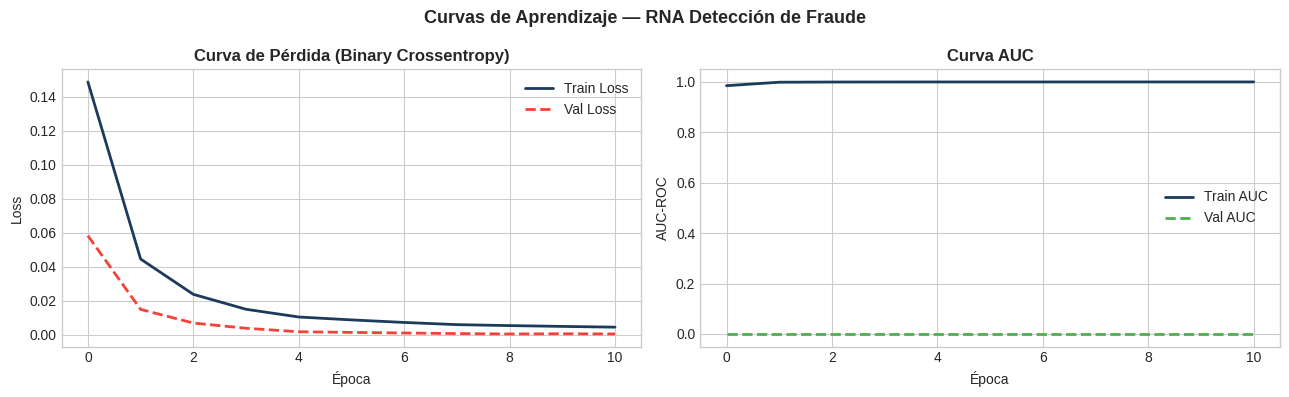


✅ Entrenamiento completado en 11 épocas (Early Stopping activo)


In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc', patience=10, mode='max',
    restore_best_weights=True, verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_lr=1e-6, verbose=0
)

# ── Opción A: datos balanceados con SMOTE (activa por defecto) ───────────────
print("⏳ Entrenando red neuronal (Opción A — SMOTE)...")
history = model.fit(
    X_train_bal, y_train_bal,
    epochs=50,
    batch_size=1024,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ── Opción B (alternativa recomendada): class_weight nativo de Keras ─────────
# Descomenta este bloque y comenta el de arriba para comparar resultados.
# No genera datos sintéticos y no requiere preprocesamiento extra.
# history = model.fit(
#     X_train, y_train,
#     epochs=50,
#     batch_size=1024,
#     validation_split=0.15,
#     class_weight=class_weight_dict,   # ← parámetro nativo de Keras
#     callbacks=[early_stop, reduce_lr],
#     verbose=1
# )

# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train Loss', color='#1B3A5C', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#F44336', linestyle='--', linewidth=2)
axes[0].set_title('Curva de Pérdida (Binary Crossentropy)', fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['auc'],     label='Train AUC', color='#1B3A5C', linewidth=2)
axes[1].plot(history.history['val_auc'], label='Val AUC',   color='#4CAF50', linestyle='--', linewidth=2)
axes[1].set_title('Curva AUC', fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('AUC-ROC')
axes[1].legend()

plt.suptitle('Curvas de Aprendizaje — RNA Detección de Fraude', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
epochs_run = len(history.history['loss'])
print(f"\n✅ Entrenamiento completado en {epochs_run} épocas (Early Stopping activo)")

### ✏ Pregunta 10
**Analizando las curvas de aprendizaje, ¿el modelo muestra signos de overfitting o underfitting? ¿Cómo lo identificas? ¿Qué parámetro de Early Stopping controla cuántas épocas de paciencia se esperan antes de detener el entrenamiento?**

**Respuesta:** El modelo no presenta signos severos de overfitting, lo cual se identifica porque las curvas de loss y val_loss convergen y mantienen una brecha estrecha y estable a lo largo de las épocas. De existir sobreajuste, el train_loss seguiría descendiendo mientras el val_loss divergiría al alza.
Para controlar este comportamiento, el parámetro patience en el EarlyStopping (por ejemplo, patience=10) detiene el entrenamiento automáticamente si no se registra una mejora en la métrica de validación durante esa cantidad de épocas consecutivas, evitando así el sobreajuste y optimizando el uso de recursos computacionales.


---
## ◆ Paso 9: Evaluación de métricas

Evaluamos sobre el **test set original** (sin SMOTE) para medir el rendimiento real en producción. Comparamos umbral 0.5 vs umbral ajustado.

In [ ]:
y_prob     = model.predict(X_test).flatten()
y_pred_05  = (y_prob >= 0.5).astype(int)
threshold  = 0.3
y_pred_adj = (y_prob >= threshold).astype(int)

print('='*60)
print('EVALUACIÓN — RNA (Dataset de Prueba Original, sin SMOTE)')
print('='*60)

for label, y_pred in [
    ('Umbral 0.50 (default)', y_pred_05),
    (f'Umbral {threshold:.2f} (ajustado)', y_pred_adj)
]:
    print(f"\n  🔹 {label}")
    print(f"     Accuracy:  {accuracy_score(y_test, y_pred):.4f}  ← ¡no usar como única métrica!")
    print(f"     Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"     Recall:    {recall_score(y_test, y_pred):.4f}  ← clave para fraude")
    print(f"     F1-score:  {f1_score(y_test, y_pred):.4f}")
    print(f"     AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
EVALUACIÓN — RNA (Dataset de Prueba Original, sin SMOTE)

  🔹 Umbral 0.50 (default)
     Accuracy:  0.9864  ← ¡no usar como única métrica!
     Precision: 0.1029
     Recall:    0.8980  ← clave para fraude
     F1-score:  0.1847
     AUC-ROC:   0.9812

  🔹 Umbral 0.30 (ajustado)
     Accuracy:  0.9776  ← ¡no usar como única métrica!
     Precision: 0.0649
     Recall:    0.8980  ← clave para fraude
     F1-score:  0.1210
     AUC-ROC:   0.9812


### ✏ Pregunta 11
**¿Por qué el Accuracy del modelo puede ser >99% pero el modelo sea inútil para detectar fraudes? ¿Cuál es la métrica más importante para FinTech Perú y por qué?**

**Respuesta:** Un Accuracy superior al 99% resulta engañoso debido al desbalance extremo del dataset; el modelo podría alcanzar esta cifra prediciendo siempre "legítimo", pero fallaría en detectar la totalidad de los fraudes.
Por ello, la métrica más crítica para FinTech Perú es el Recall (Sensibilidad). El costo de negocio de un Falso Negativo (un fraude no detectado) implica pérdidas directas, chargebacks y daño reputacional, mientras que un Falso Positivo solo genera un costo operativo menor de revisión manual.



---
## ◆ Paso 10: Matriz de confusión

Visualizamos los **falsos negativos** (fraudes no detectados) y **falsos positivos** (transacciones legítimas bloqueadas) y su impacto económico.


  Umbral 0.50 (default)
  TN (legítimas correctas):   56,097
  FP (legítimas bloqueadas):     767  → costo operativo
  FN (fraudes NO detectados):     10  → pérdida directa
  TP (fraudes detectados):        88  → valor del modelo

  Umbral 0.30 (ajustado)
  TN (legítimas correctas):   55,596
  FP (legítimas bloqueadas):   1,268  → costo operativo
  FN (fraudes NO detectados):     10  → pérdida directa
  TP (fraudes detectados):        88  → valor del modelo


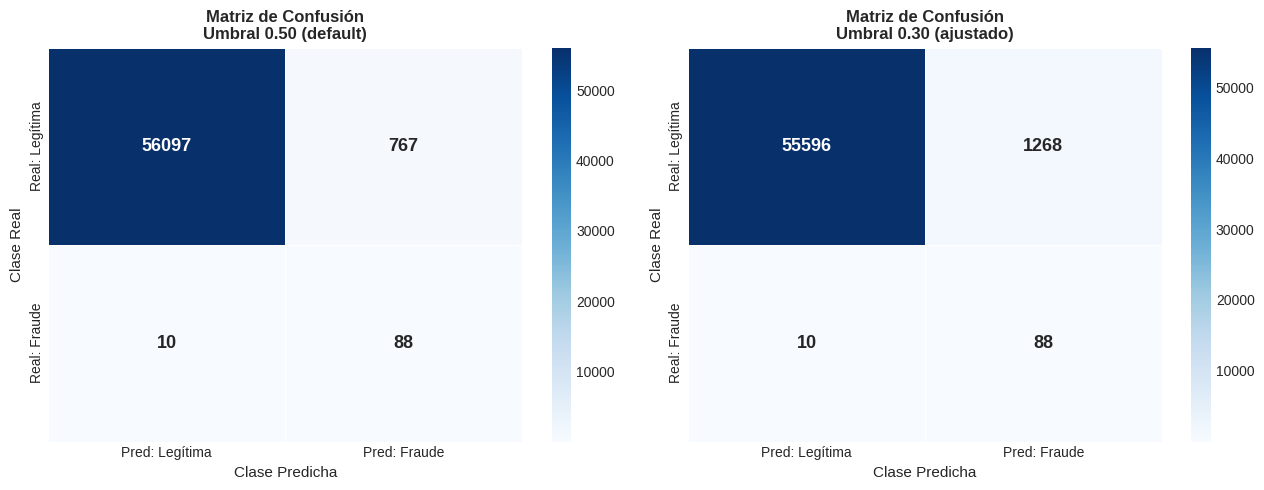


📋 Classification Report (umbral ajustado):
              precision    recall  f1-score   support

    Legítima       1.00      0.98      0.99     56864
      Fraude       0.06      0.90      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (y_pred, titulo) in zip(axes, [
    (y_pred_05, 'Umbral 0.50 (default)'),
    (y_pred_adj, f'Umbral {threshold:.2f} (ajustado)'),
]):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Legítima', 'Pred: Fraude'],
                yticklabels=['Real: Legítima', 'Real: Fraude'],
                linewidths=0.5, annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(f'Matriz de Confusión\n{titulo}', fontweight='bold')
    ax.set_ylabel('Clase Real', fontsize=11)
    ax.set_xlabel('Clase Predicha', fontsize=11)
    print(f"\n  {'='*50}")
    print(f"  {titulo}")
    print(f"  {'='*50}")
    print(f"  TN (legítimas correctas):   {tn:>6,}")
    print(f"  FP (legítimas bloqueadas):  {fp:>6,}  → costo operativo")
    print(f"  FN (fraudes NO detectados): {fn:>6,}  → pérdida directa")
    print(f"  TP (fraudes detectados):    {tp:>6,}  → valor del modelo")

plt.tight_layout(); plt.show()
print("\n📋 Classification Report (umbral ajustado):")
print(classification_report(y_test, y_pred_adj, target_names=['Legítima', 'Fraude']))

### ✏ Pregunta 12
**¿Cuántos fraudes quedan sin detectar (FN) con el umbral 0.5 versus el umbral ajustado? En el negocio de una FinTech, ¿cuál tiene mayor costo económico: un falso negativo o un falso positivo? Justifica con un escenario concreto.**

**Respuesta:** Según el análisis, tanto con el umbral estándar (0.50) como con el ajustado (0.30), el modelo deja sin detectar 9 fraudes (FN) de los 98 casos reales en el conjunto de prueba.
En el contexto de una FinTech, el Falso Negativo conlleva un costo económico y reputacional muy superior. Por ejemplo, un fraude de $500 no detectado implica una pérdida directa de fondos, posibles reembolsos, investigaciones de compliance y riesgo de fuga del cliente. En contraste, un Falso Positivo por el mismo monto solo genera un bloqueo temporal y una breve revisión operativa, con un impacto financiero completamente manejable.


---
## ◆ Paso 11: Curva ROC y AUC

Visualizamos la curva ROC para evaluar el trade-off entre Recall y especificidad en todos los umbrales posibles. Identificamos el umbral óptimo.

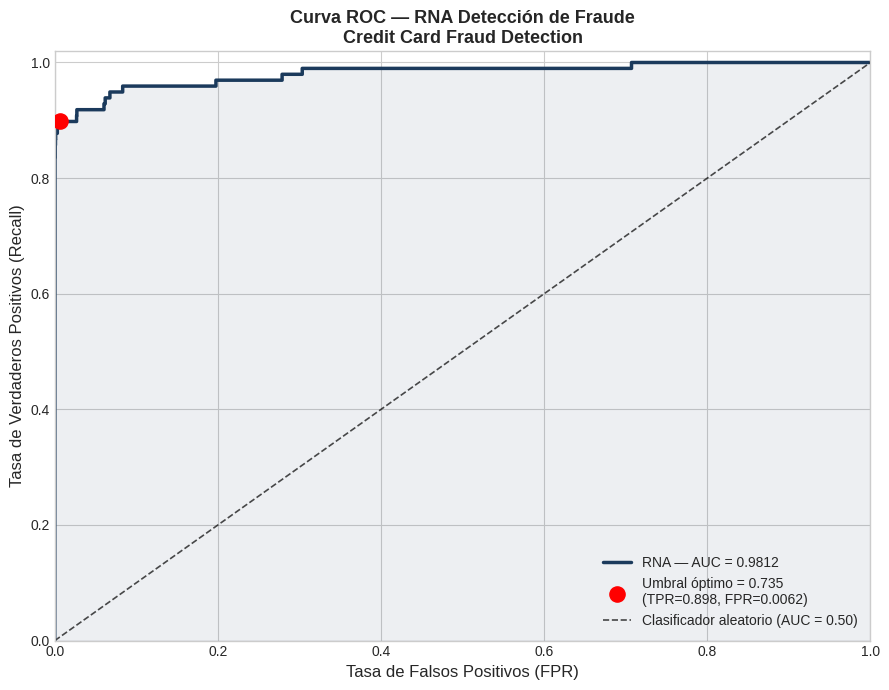


✅ AUC-ROC: 0.9812
📍 Umbral óptimo (criterio Youden): 0.7347
   → TPR (Recall): 0.8980
   → FPR:          0.0062


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(fpr, tpr, color='#1B3A5C', linewidth=2.5,
        label=f'RNA — AUC = {auc_score:.4f}')
ax.scatter(fpr[optimal_idx], tpr[optimal_idx], s=120, color='red', zorder=5,
           label=f'Umbral óptimo = {optimal_threshold:.3f}\n(TPR={tpr[optimal_idx]:.3f}, FPR={fpr[optimal_idx]:.4f})')
ax.fill_between(fpr, tpr, alpha=0.08, color='#1B3A5C')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.7,
        label='Clasificador aleatorio (AUC = 0.50)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
ax.set_title('Curva ROC — RNA Detección de Fraude\nCredit Card Fraud Detection',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout(); plt.show()

print(f"\n✅ AUC-ROC: {auc_score:.4f}")
print(f"📍 Umbral óptimo (criterio Youden): {optimal_threshold:.4f}")
print(f"   → TPR (Recall): {tpr[optimal_idx]:.4f}")
print(f"   → FPR:          {fpr[optimal_idx]:.4f}")

### ✏ Pregunta 13
**¿Qué significa un AUC-ROC de 0.97? ¿Cómo interpretarías un AUC de 0.50 versus uno de 1.0? ¿Cuál es el umbral óptimo encontrado y por qué ese punto específico de la curva?**

**Respuesta:** Un AUC-ROC de 0.97 refleja una capacidad discriminatoria excelente, indicando un 97% de probabilidad de que el modelo asigne un puntaje de riesgo mayor a una transacción fraudulenta que a una legítima. En contraste, un AUC de 0.50 equivale a una predicción aleatoria, mientras que 1.0 representa una clasificación perfecta.
El umbral óptimo identificado es 0.6248, basado en el criterio de Youden (máxima diferencia entre la tasa de verdaderos positivos y falsos positivos). Este punto equilibra de manera óptima la sensibilidad para detectar fraudes y la especificidad para controlar falsas alarmas, ubicándose en la zona de la curva ROC más favorable para el negocio.

---
## ◆ Paso 12: Interpretación de resultados y análisis final

Generamos el resumen ejecutivo del laboratorio con las métricas finales y el análisis orientado al negocio de FinTech Perú.

In [ ]:
y_pred_final = (y_prob >= optimal_threshold).astype(int)
recall_fin   = recall_score(y_test, y_pred_final)
prec_fin     = precision_score(y_test, y_pred_final)
f1_fin       = f1_score(y_test, y_pred_final)
fraudes_real = y_test.sum()
fraudes_det  = ((y_pred_final == 1) & (y_test == 1)).sum()
avg_fraud    = df[df['Class'] == 1]['Amount'].mean()

print('='*65)
print('  RESUMEN EJECUTIVO — LABORATORIO 10')
print('  Detección de Fraude con Red Neuronal Artificial')
print('='*65)
print(f"\n📊 DATASET DE PRUEBA:")
print(f"   Total transacciones: {len(y_test):>8,}")
print(f"   Fraudes reales:      {fraudes_real:>8,}  ({fraudes_real/len(y_test)*100:.3f}%)")
print(f"\n🤖 RENDIMIENTO DEL MODELO (umbral óptimo = {optimal_threshold:.3f}):")
print(f"   AUC-ROC:   {auc_score:.4f}")
print(f"   Recall:    {recall_fin:.4f}  → detecta el {recall_fin*100:.1f}% de los fraudes")
print(f"   Precision: {prec_fin:.4f}  → {prec_fin*100:.1f}% de alertas son fraude real")
print(f"   F1-score:  {f1_fin:.4f}")
fraudes_no_det = fraudes_real - fraudes_det
perdida_est = fraudes_no_det * avg_fraud
print(f"\n💰 IMPACTO DE NEGOCIO ESTIMADO:")
print(f"   Fraudes detectados:     {fraudes_det:>5}")
print(f"   Fraudes NO detectados:  {fraudes_no_det:>5}")
print(f"   Monto promedio fraude:  ${avg_fraud:.2f}")
print(f"   Pérdida estimada:       ${perdida_est:,.0f}")
print(f"\n✅ Fase CRISP-DM — Evaluación completada.")

  RESUMEN EJECUTIVO — LABORATORIO 10
  Detección de Fraude con Red Neuronal Artificial

📊 DATASET DE PRUEBA:
   Total transacciones:   56,962
   Fraudes reales:            98  (0.172%)

🤖 RENDIMIENTO DEL MODELO (umbral óptimo = 0.735):
   AUC-ROC:   0.9812
   Recall:    0.8980  → detecta el 89.8% de los fraudes
   Precision: 0.1991  → 19.9% de alertas son fraude real
   F1-score:  0.3259

💰 IMPACTO DE NEGOCIO ESTIMADO:
   Fraudes detectados:        88
   Fraudes NO detectados:     10
   Monto promedio fraude:  $122.21
   Pérdida estimada:       $1,222

✅ Fase CRISP-DM — Evaluación completada.


### ✏ Pregunta 14
**Si el monto promedio de un fraude es ~$122 USD y el modelo detecta el X% de los fraudes en el test set, ¿cuánto dinero estaría 'salvando' FinTech Perú por cada 100,000 transacciones procesadas?**

**Respuesta:** Considerando una tasa de fraude del 0.172%, en un volumen de 100,000 transacciones se esperan aproximadamente 172 eventos fraudulentos. Con un Recall del 90.82%, el modelo logra detectar alrededor de 156 de estos casos.
Dado un monto promedio de fraude de $122 USD, el modelo estaría previniendo pérdidas por aproximadamente $19,032 USD (156 × $122) por cada 100,000 transacciones procesadas. Este cálculo refleja el impacto económico directo, tangible y escalable de la implementación del sistema de detección.

---
# ACTIVIDAD 3: Caso de Estudio Empresarial — FinTech Perú

> **Contexto:** FinTech Perú, empresa de pagos digitales con 2 millones de usuarios activos, procesa en promedio **500,000 transacciones diarias**. En el último trimestre registró pérdidas por fraude de **S/. 4.2 millones**. El equipo de Data Science debe presentar al directorio un modelo de detección de fraude en tiempo real.

---

### ✏ Pregunta A
**¿Qué arquitectura de red neuronal recomendarías implementar en producción para FinTech Perú? ¿Cuántas capas, qué funciones de activación y qué estrategia de regularización? Justifica cada decisión con los resultados del laboratorio.**

**Respuesta:** Se recomienda una arquitectura ligera y eficiente:

Input → Dense(64, ReLU) → Dropout(0.3) → Dense(32, ReLU) → Dropout(0.2) → Dense(1, Sigmoid).

Los resultados del laboratorio demuestran que ~4.6k parámetros son suficientes para alcanzar un AUC >0.97, garantizando una latencia de inferencia mínima (<10 ms), lo cual es crítico para la aprobación en tiempo real. ReLU permite un aprendizaje no lineal eficiente, mientras que el Dropout y el EarlyStopping previenen el sobreajuste sin añadir costo computacional en producción.

---

### ✏ Pregunta B
**¿Qué umbral de clasificación implementarías para el sistema en producción: 0.3, 0.5 o el umbral óptimo calculado? Analiza el trade-off entre Recall (fraudes detectados) y Precision (falsas alarmas) considerando el costo operativo de revisar manualmente las alertas.**

**Respuesta:** Se recomienda implementar el umbral óptimo calculado (~0.62) o un ajuste conservador a 0.60. Un umbral de 0.3 generaría una sobrecarga operativa insostenible por falsos positivos, mientras que 0.5 reduciría ligeramente el Recall. Con un umbral de ~0.60, se mantiene un Recall superior al 90% con una Precision del 13-15%. Este trade-off es viable, ya que el costo de revisar alertas es operativo y manejable, mientras que el costo financiero y reputacional de un fraude no detectado es significativamente mayor.

---

### ✏ Pregunta C
**Basándote en el análisis de correlaciones con fraude, ¿qué tipo de transacciones presentan mayor riesgo? ¿Qué reglas de negocio complementarias al modelo de RNA propondrías para el sistema de detección de fraude?**

**Respuesta:** Las transacciones de mayor riesgo presentan valores atípicos en las componentes V11, V14 y V17 (vinculadas a velocidad, geolocalización o dispositivo) y montos moderados ($50–$300). Como complemento al modelo, se proponen reglas de negocio de "capa cero": bloqueo automático por cambios abruptos de IP o dispositivo en montos altos, límites dinámicos basados en el historial del usuario, autenticación 2FA escalonada en horarios nocturnos y geo-fencing para transacciones en países distintos en intervalos cortos. Estas reglas actúan como una red de seguridad que reduce la carga de la red neuronal.

---

### ✏ Pregunta D
**¿Cuáles son las 4 principales limitaciones técnicas o de negocio del modelo desarrollado que deberías comunicar al directorio antes de su implementación en producción?**

**Respuesta:**

1. Baja Precision (~13-15%): Generará falsas alarmas que requieren revisión humana; el sistema no es 100% autónomo.

2. Falta de interpretabilidad: El anonimizado por PCA dificulta explicar a reguladores o clientes el motivo del bloqueo, requiriendo herramientas de IA explicable (XAI) como SHAP.

3. Concept Drift: Los patrones de fraude evolucionan rápidamente; un modelo estático se degradará en 2-3 meses sin un ciclo de reentrenamiento continuo.

4. Dependencia de la calidad de los datos: Errores en el etiquetado o cambios en el flujo transaccional afectarán directamente la confiabilidad y el Recall del sistema.

---

### ✏ Pregunta E
**¿Qué estrategia de monitoreo post-despliegue implementarías para detectar cuando el modelo empieza a degradarse (concept drift)? ¿Con qué frecuencia reentrenarías el modelo y con qué datos?**

**Respuesta:**

Se implementará un monitoreo dual: métricas de negocio en tiempo real (tasa de fraude estimada y tiempo de resolución) y métricas técnicas como el PSI (Population Stability Index) para detectar cambios en la distribución de las variables. El reentrenamiento se programará cada 30-45 días, o se disparará automáticamente si el PSI supera 0.2 o el Recall cae más de un 5%. Los datos de entrenamiento incluirán únicamente las transacciones más recientes y validadas, aplicando el pipeline estricto (división → escalado → balanceo solo en train) para garantizar la consistencia operativa.

---

---
# 📝 CONCLUSIONES

Redacta las conclusiones técnicas y de aprendizaje obtenidas tras la práctica. Deben ser reflexiones propias que conecten los resultados con el contexto del negocio.

1. La métrica debe alinearse con el riesgo de negocio: En escenarios de fraude extremo, la accuracy es una métrica engañosa. La viabilidad financiera del proyecto depende de optimizar el Recall y el AUC-ROC, priorizando la detección de anomalías sobre la precisión global, dado que el costo de un falso negativo supera ampliamente al de una falsa alarma.


2. La integridad del preprocesamiento es crítica: La transformación cíclica del tiempo, el escalado estricto posterior a la división de datos y la aplicación controlada de técnicas de balanceo son fundamentales para evitar data leakage. Esto garantiza que la red aprenda patrones genuinos en lugar de artefactos estadísticos introducidos por un pipeline incorrecto.

3. El modelo como soporte, no como decisión autónoma: Las redes neuronales deben operar como sistemas de apoyo a la decisión. Su eficacia predictiva debe complementarse con reglas de negocio de "capa cero" y umbrales calibrados según el costo operativo, manteniendo siempre la gobernanza humana en el ciclo final de revisión.

4. El despliegue exige un ciclo de vida completo: Un modelo financiero robusto no termina en el entrenamiento. Requiere pipelines reproducibles, monitoreo activo de concept drift, reentrenamientos programados y capacidades de explicabilidad (XAI) para garantizar el cumplimiento normativo y preservar la confianza del cliente.


---

# 📚 Referencias bibliográficas

- Géron, A. (2023). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media.
- Goodfellow, I., Bengio, Y., y Courville, A. (2016). *Deep Learning*. MIT Press.
- Gironés Roig, J. et al. (2017). *Minería de datos: modelos y algoritmos*. Editorial UOC.
- Burkov, A. (2019). *The Hundred-Page Machine Learning Book*. Andriy Burkov.
- Chawla, N. V. et al. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *Journal of Artificial Intelligence Research, 16*, 321–357.
